# Step 1:
# Load and Explore Dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("california_housing.csv")

# Information of the dataset
print("Info of the dataset:")
print(df.info())

# 1st five rows of the dataset
print("\n1st five rows of the dataset:")
print(df.head())


Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

1st five rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0  

In [ ]:
# Check for the null value
print("Null value in the dataset:")
print(df.isnull().sum())

Null value in the dataset:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# Since total_bedrooms contains null values replace it with suitable data
ratio = (df['total_rooms'] / df['total_bedrooms']).mean()

# Using the ratio as number of total bedrooms may depends on number of total rooms
df['total_bedrooms'] = df['total_bedrooms'].fillna((df.total_rooms / ratio)).round()

# Check for null values
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


# Step 2:
# Encoding Categorical Variables(One Hot Encoding)

In [ ]:
# Encode Categorical column to Numerical
df_encoded = pd.get_dummies(df['ocean_proximity'], prefix='ocean')
df_combined = pd.concat([df.drop('ocean_proximity', axis=1), df_encoded], axis=1)

print("Encoded dataset:")
print(df_combined.head())

Encoded dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  ocean_<1H OCEAN  \
0       322.0       126.0         8.3252            452600.0            False   
1      2401.0      1138.0         8.3014            358500.0            False   
2       496.0       177.0         7.2574            352100.0            False   
3       558.0       219.0         5.6431            341300.0            False   
4       565.0       259.0         3.8462            342200.0            False   

   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY

## Step 3:

### Statistical Analysis

In [ ]:
# Describtion of the dataset
print("Statistical Description of the dataset:")
print("Mean: \n", df_combined.mean())
print("\nMedian: \n", df_combined.median())
print("\nStandard Deviation: \n", df_combined.std())
print('\nMode: \n', df_combined.mode().iloc[0])
print('\nVariance: \n', df_combined.var())

Statistical Description of the dataset:
Mean: 
 longitude               -119.569704
latitude                  35.631861
housing_median_age        28.639486
total_rooms             2635.763081
total_bedrooms           537.631928
population              1425.476744
households               499.539680
median_income              3.870671
median_house_value    206855.816909
ocean_<1H OCEAN            0.442636
ocean_INLAND               0.317393
ocean_ISLAND               0.000242
ocean_NEAR BAY             0.110950
ocean_NEAR OCEAN           0.128779
dtype: float64

Median: 
 longitude               -118.4900
latitude                  34.2600
housing_median_age        29.0000
total_rooms             2127.0000
total_bedrooms           435.0000
population              1166.0000
households               409.0000
median_income              3.5348
median_house_value    179700.0000
ocean_<1H OCEAN            0.0000
ocean_INLAND               0.0000
ocean_ISLAND               0.0000
ocean_NEAR BAY

# Step 4:

## Data Visualization

In [ ]:
df_combined.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.631928,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,420.800725,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,295.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# **Distribution of Median House Value**

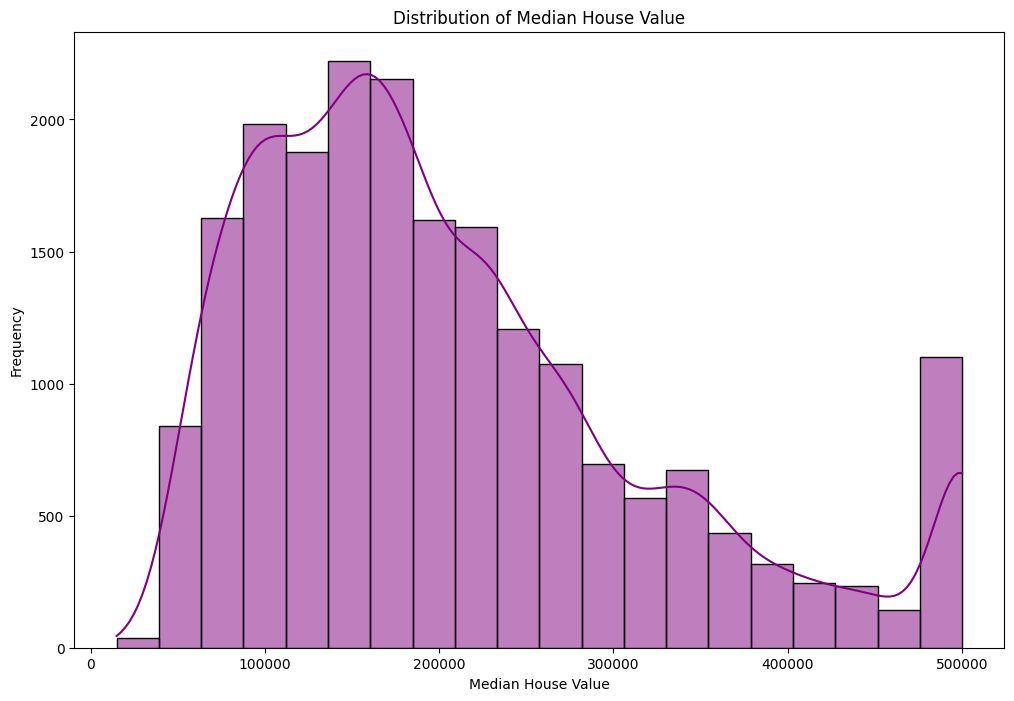

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


plt.figure(figsize=(12, 8))
sns.histplot(data=df_combined, x='median_house_value', bins=20, kde=True, color='purple', alpha=0.5)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

plt.show()

## Distribution of population by Ocean Proximity

/tmp/ipython-input-3798533662.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Ocean Proximity")


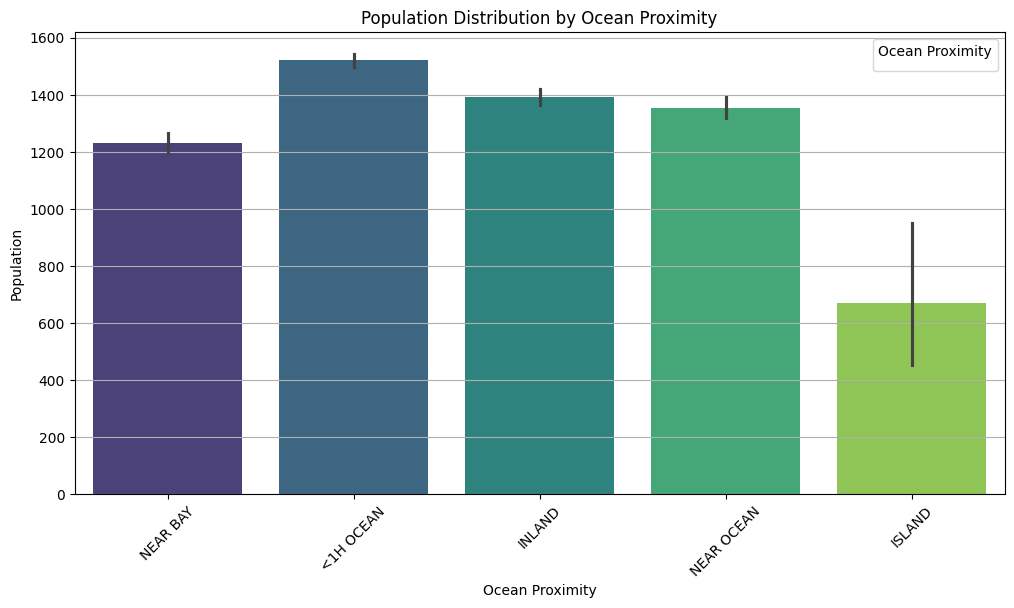

In [ ]:
plt.figure(figsize=(12, 6))

# Create the violin plot
sns.barplot(x=df['ocean_proximity'], y=df_combined['population'], hue=df['ocean_proximity'], palette="viridis")

plt.title('Population Distribution by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## Pie Chart for Median Income Distribution

income_group
<$20k         2457
$20k–$30k     4946
$30k-$40k     5150
$40k–$50k     3598
$50k-$60k     2127
$60k–$80k     1672
$80k–$120k     577
$120k+         113
Name: count, dtype: int64


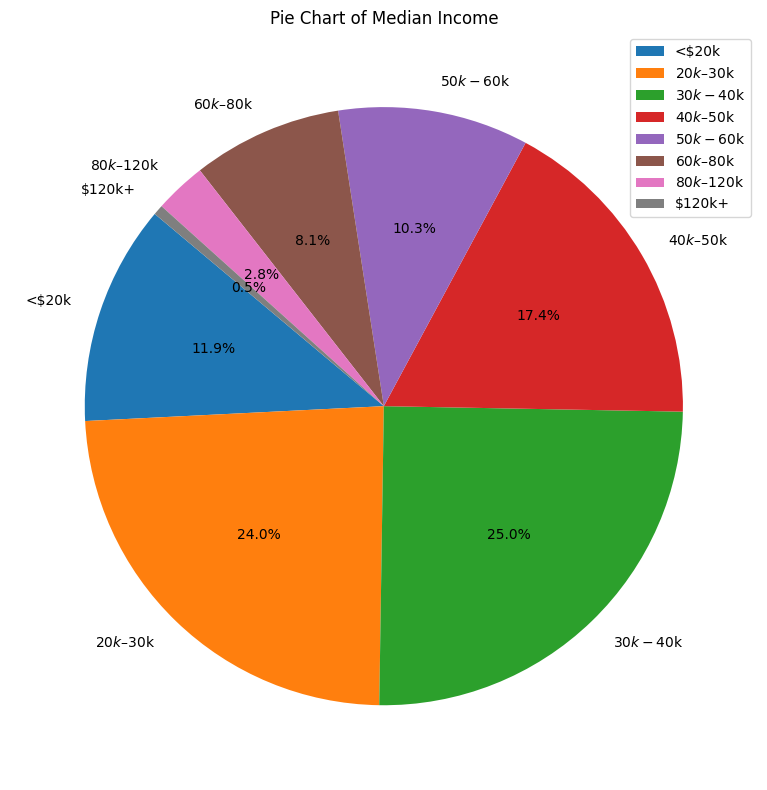

In [ ]:
# Pie chart for median income

# Define finer-grained bins and labels
bins = [0, 2, 3, 4, 5, 6, 8, 12, 16]
labels = ['<$20k', '$20k–$30k', '$30k-$40k', '$40k–$50k', '$50k-$60k', '$60k–$80k', '$80k–$120k', '$120k+']

# Create a new column for income categories
df['income_group'] = pd.cut(df['median_income'], bins=bins, labels=labels)
income_counts = df['income_group'].value_counts().sort_index()
print(income_counts)

plt.figure(figsize=(8, 8))
plt.pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Median Income')
plt.legend()
plt.tight_layout()
plt.show()

## Bar Plot

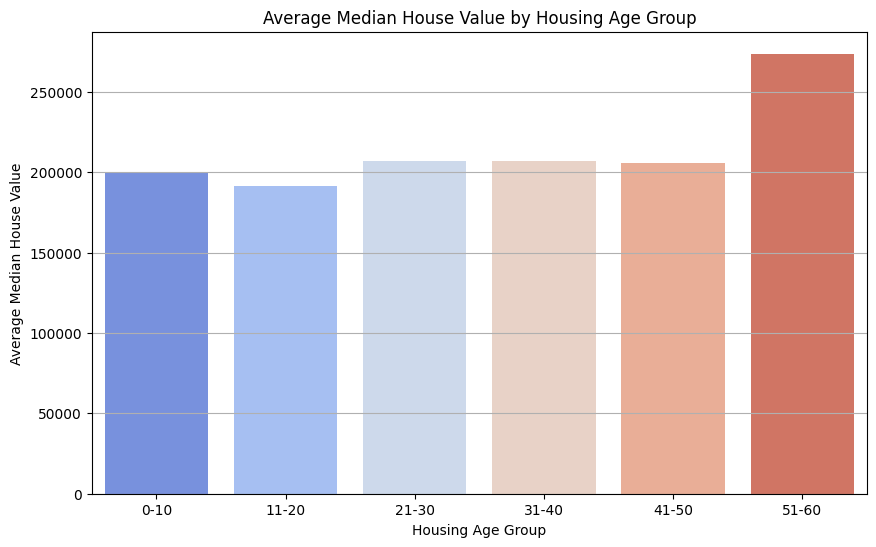

In [ ]:
# Bin housing age into categories
df_combined['age_group'] = pd.cut(df_combined['housing_median_age'],
                                  bins=[0, 10, 20, 30, 40, 50, 60],
                                  labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60'])

# Compute average house value by age group
age_value = df_combined.groupby('age_group', observed=False)['median_house_value'].mean().reset_index()


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=age_value, x='age_group', y='median_house_value', hue='age_group', palette='coolwarm')
plt.title('Average Median House Value by Housing Age Group')
plt.xlabel('Housing Age Group')
plt.ylabel('Average Median House Value')
plt.grid(axis='y')
plt.show()


In [ ]:
print(age_value)
df_combined.head()

  age_group  median_house_value
0      0-10       200263.254939
1     11-20       191181.627223
2     21-30       206801.590478
3     31-40       206662.165747
4     41-50       205860.395776
5     51-60       273687.564724


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_<1H OCEAN,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN,age_group
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False,41-50
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False,21-30
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False,51-60
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False,51-60
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False,51-60


# Scatter Plot

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   

   population  households  median_income  median_house_value  ocean_<1H OCEAN  \
2       496.0       177.0         7.2574            352100.0            False   
3       558.0       219.0         5.6431            341300.0            False   
4       565.0       259.0         3.8462            342200.0            False   
5       413.0       193.0         4.0368            269700.0            False   
6      1094.0       514.0         3.6591            299200.0            False   

   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY  ocean_NEAR OCEA

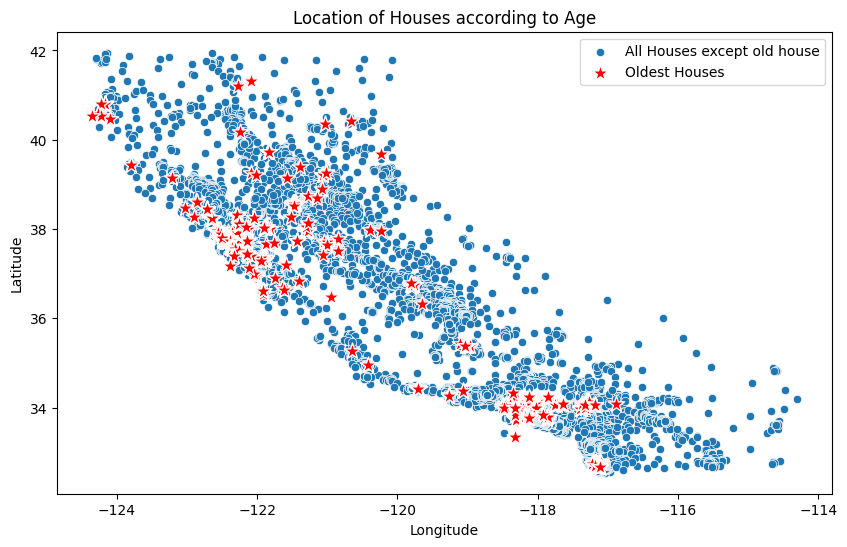

In [ ]:
# Find the house of age group 51-60
df_oldest_house = df_combined[df_combined['age_group'] == '51-60']
df_except_oldest_house = df_combined[df_combined['age_group'] != '51-60']
print(df_oldest_house.head())
# Plot the longitude and lattitude
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_except_oldest_house, x='longitude', y='latitude')
sns.scatterplot(data=df_oldest_house, x='longitude', y='latitude', color='red', marker="*", s=150)
plt.title('Location of Houses according to Age')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(labels=['All Houses except old house', 'Oldest Houses'])
plt.show()

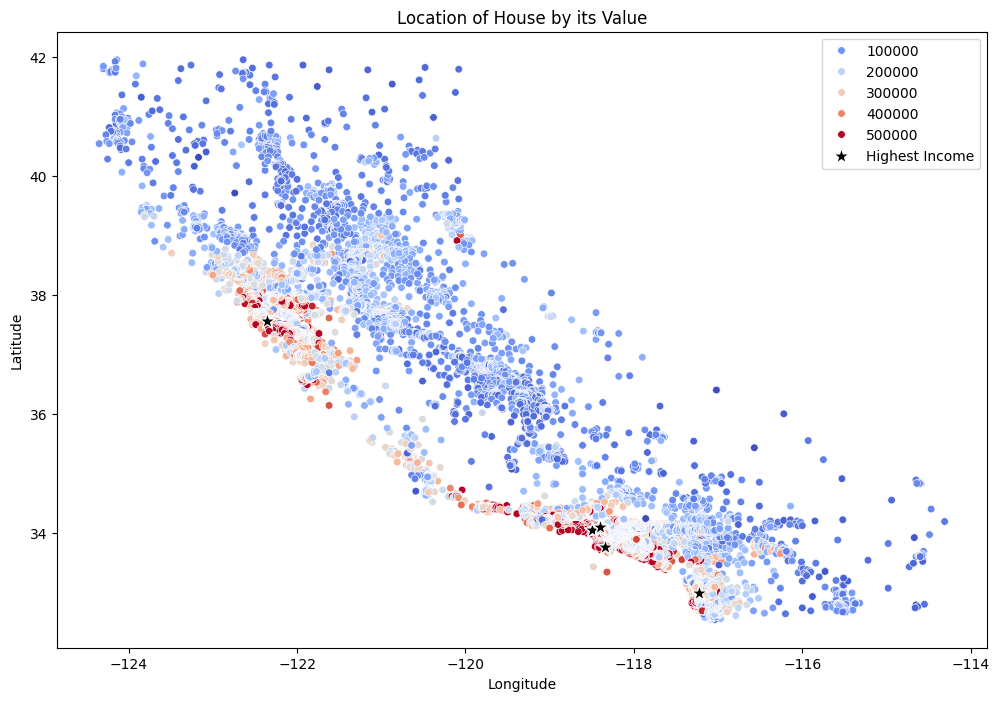

In [ ]:
df_highest_income = df_combined.sort_values(by='median_income', ascending=False).head(10)
# Scatter Plot of Longitude with latitude
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_combined, x='longitude', y='latitude', hue='median_house_value', palette="coolwarm", s=30, edgecolor='white')
sns.scatterplot(data=df_highest_income, x='longitude', y='latitude', color='k', marker="*", s=150, label="Highest Income")
plt.title('Location of House by its Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

# Correlation and Heatmap

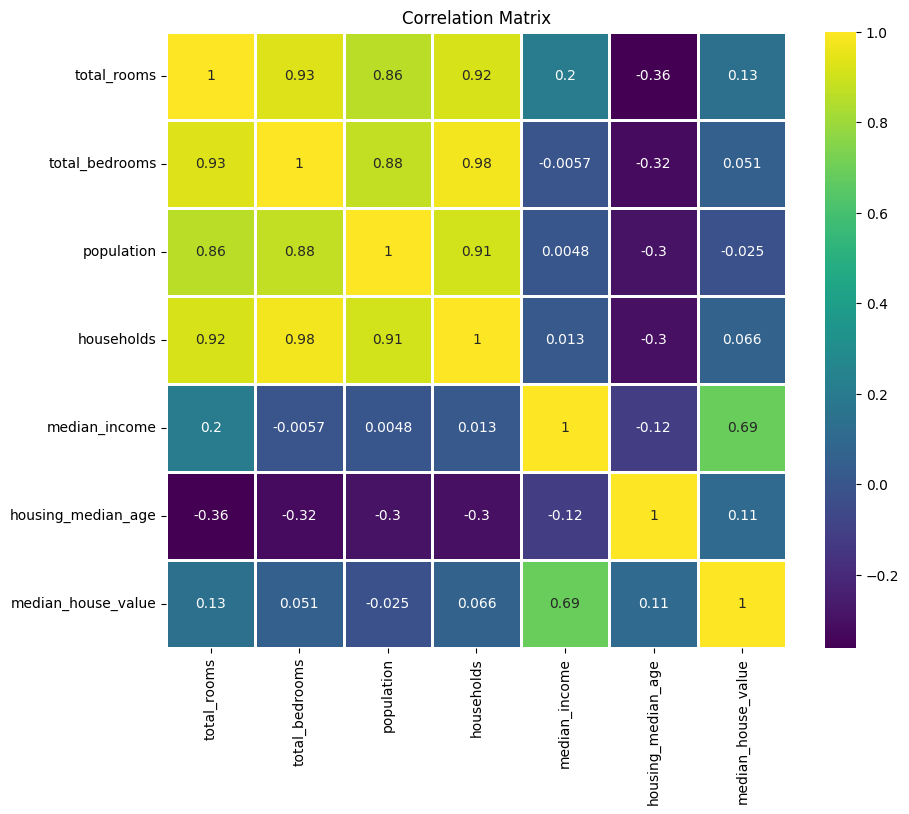

In [ ]:
# Plotting correlation between some columns
columns = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'housing_median_age', 'median_house_value']
corr_matrix = df_combined[columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidth=1)
plt.title('Correlation Matrix')
plt.show()

Key Insights
1. Total rooms, total bedrooms, households and population show a strong positive correlation with each other. This suggests that more homes or apartments typically mean more rooms and more people.

2.  Median income is strongly correlated (~0.69) with median house value.
    The higher the income, the more expensive the homes.
    
3.  Population and rooms have a weak correlation with median house value and median income.
Meaning: More people or larger homes don’t automatically mean pricier housing or higher income— quantity doesn’t equal value.




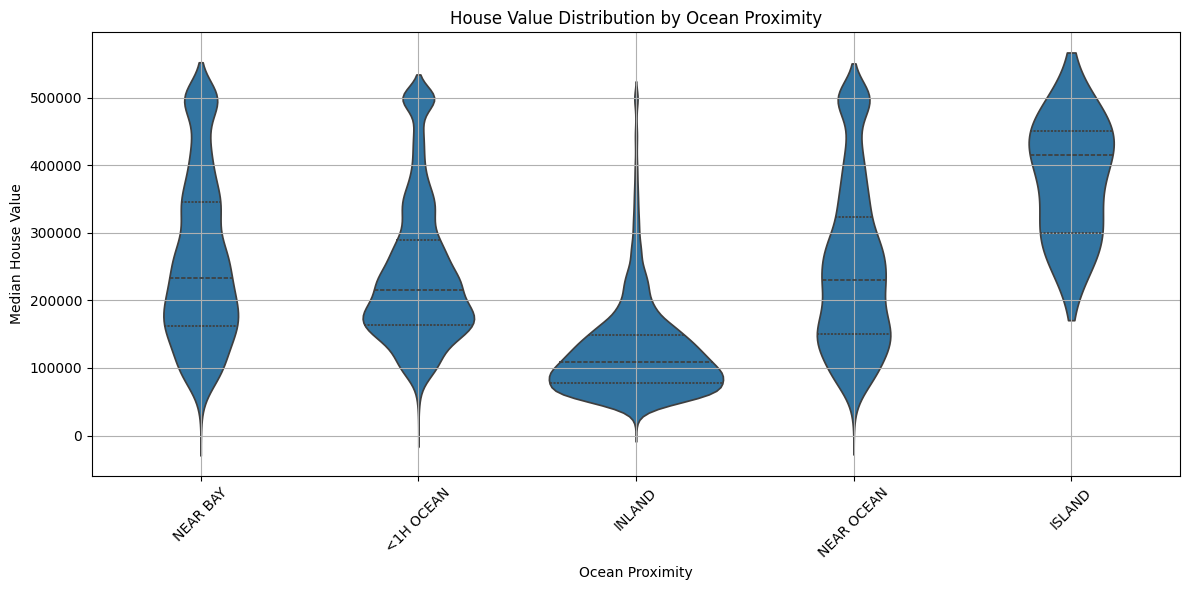

In [ ]:
plt.figure(figsize=(12, 6))

# Create the violin plot
sns.violinplot(x=df['ocean_proximity'], y=df_combined['median_house_value'], inner='quartile')

plt.title('House Value Distribution by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

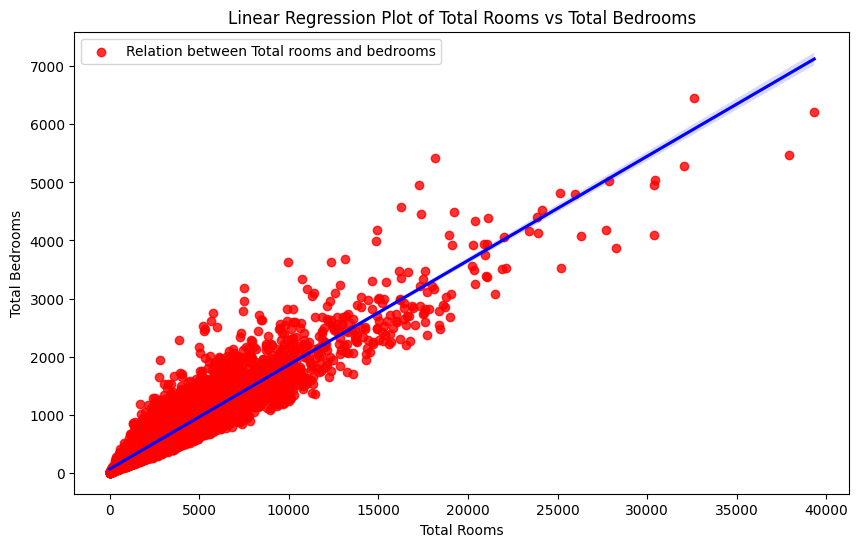

In [ ]:
# Linear regression plot
plt.subplots(figsize=(10, 6))
sns.regplot(data=df_combined, x='total_rooms', y='total_bedrooms', scatter_kws={'color':'red'}, line_kws={'color':'blue'}, ci=95, label="Relation between Total rooms and bedrooms")

plt.legend()
plt.show()


# **Summary**

Interesting Insights:

1. “Usually population density meant higher prices as People tend to concentrate in highly developed areas. As a result, housing prices are usually higher in these regions.
      But the data says otherwise...”

2. “Ultimately, income and location mattered far more than property size or population.